In [ ]:
# Do only once: 

import os

# move up from notebooks -> project root
os.chdir(os.path.join(os.getcwd(),os.pardir))
print("Working dir is now:", os.getcwd())

DATA_PATH = "/Users/adrian/Documents/01_projects/14_4D_lab/data"
OUTPUT_PATH = "/Users/adrian/Documents/01_projects/connectome_experiment_ai_gen/results"

Working dir is now: /Users/adrian/Documents


In [2]:
from __future__ import annotations

import logging
from typing import Dict, List, Tuple, Iterable, Optional

import numpy as np
import scipy.io
import scipy.sparse as sp

try:
    from netneurotools.networks import threshold_network
except ImportError:  # pragma: no cover - optional dependency
    threshold_network = None  # type: ignore

logger = logging.getLogger(__name__)

In [3]:
import matplotlib.pyplot as plt

In [4]:
mat_file = "/Users/adrian/Documents/01_projects/12_ma_thesis/data/raw/consensus_connectomes_from_70_young_adults_10mb.mat"

# Extract 68 and 114 node matrices from LauConsensus

In [5]:
import numpy as np
import scipy.io as sio

def load_lauconsensus(path, n_regions=68):
    """
    Returns (W, coords) for the requested parcellation size (68 or 114).
    W is weighted structural adjacency (N x N), coords is (N x 3).
    """
    mat = sio.loadmat(path, squeeze_me=True)
    cell = mat['LauConsensus'].item()      # tuple: (5x5 array, 8x1 labels)
    matrices = cell[0]                     # 5x5 object array

    # Map row index by size: first col holds N x N adjacencies
    row_idx = None
    for i in range(matrices.shape[0]):
        A = matrices[i, 0]
        if isinstance(A, np.ndarray) and A.shape[0] == A.shape[1] == n_regions:
            row_idx = i
            break
    if row_idx is None:
        raise ValueError(f"No parcellation with N={n_regions} found.")

    W = matrices[row_idx, 0].astype(float)  # weighted adjacency
    C = matrices[row_idx, 3].astype(float)  # coordinates (N x 3)

    # clean: zero diagonal and symmetrize just in case
    np.fill_diagonal(W, 0.0)
    W = (W + W.T) / 2.0
    return W, C

# Example:
W68, C68 = load_lauconsensus(mat_file, n_regions=68)
W114, C114 = load_lauconsensus(mat_file, n_regions=114)


In [6]:
mat = sio.loadmat("/Users/adrian/Downloads/neonatal_generative_network_modeling-main/preprocessed/binarized_connectomes.mat", squeeze_me=True)
data = mat["binarized_connectomes"].shape

/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/scipy/io/matlab/_mio.py:227: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Considerscipy.io.matlab._mio5.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)


In [7]:
W68.shape, C68.shape, W114.shape, C114.shape
# ((68, 68), (68, 3), (114, 114), (114, 3))

((68, 68), (68, 3), (114, 114), (114, 3))

# bctpy: Threshold to equal density (and compute a few meausres - did not work too well)

In [8]:
import numpy as np
import bct

def coords_to_dist(coords):
    # Euclidean pairwise distances
    diffs = coords[:, None, :] - coords[None, :, :]
    return np.linalg.norm(diffs, axis=-1)

def prep_for_bctpy(W, coords, retain=0.20):
    """
    retain: proportion (0..1). For 20% density, pass 0.20.
    Returns binary adjacency B at that density and distance matrix D.
    """
    # bct.threshold_proportional keeps strongest retain*100 % edges
    W_thr = bct.threshold_proportional(W.copy(), retain)
    print(W_thr.shape, W_thr.sum(), W_thr.mean())
    # convert to binary undirected
    B = (W_thr > 0).astype(int)
    B = np.triu(B, 1); B = B + B.T
    D = coords_to_dist(coords)
    np.fill_diagonal(D, 0.0)
    return B, D

B68, D68 = prep_for_bctpy(W68, C68, retain=0.20)
print(B68.shape, B68.sum(), B68.mean())

# Example BCT measures
geff = bct.efficiency_bin(B68)                 # global efficiency (binary)
# Ci, Q  = bct.modularity_und(B68)               # community + modularity
# Communicability (binary)
# Gcomm  = bct.communicability_bin(B68)
# avg_comm = Gcomm.sum() - np.trace(Gcomm)       # (one way to summarise)
# Wiring cost (mean Euclidean edge length)
edge_idx = np.triu(B68, 1).astype(bool)
wiring_cost = D68[edge_idx].mean()

print(geff, wiring_cost)
# print(geff, Q, avg_comm, wiring_cost)


(68, 68) 6.668533456559559 0.0014421568893943683
(68, 68) 912 0.1972318339100346
0.5497146619841967 44.90821106964248


# Damicelli-style reservoirs: Conn2res (direct "connectome -> resevoir")

In [9]:
import numpy as np
from neurogym.conn2res import reservoirs, tasks, readouts

# Option A: use weighted W; Option B: use binary B
A = W68.copy()    # or B68

# (Recommended) scale spectral radius to < 1 for ESN-like stability
eig_max = max(abs(np.linalg.eigvals(A)))
W_scaled = (A / (eig_max + 1e-12)) * 0.9

res = reservoirs.ConnectomeReservoir(W=W_scaled, dynamics="tanh")
# Minimal test task (e.g., memory capacity or NARMA)
x, y = tasks.make_memory_capacity_input(n_steps=2000, max_lag=20)
R = res.run(x)
Wout = readouts.RidgeCV().fit(R, y)
yhat = Wout.predict(R)

# Compute your metric (memory capacity, prediction error, etc.)


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


AttributeError: 'dict' object has no attribute 'all'

In [10]:
# Example for a connectome in bio2art: Seeing how this data looks like
 
file_to_open = "/Users/adrian/Documents/01_projects/12_ma_thesis/bio2art-master/bio2art/connectomes/C_Human_Betzel_Normalized.npy"

network_original = np.load(file_to_open)
network_original.shape, network_original.mean(), network_original.std()

((57, 57),
 np.float64(5.773965648905547e-05),
 np.float64(0.0002256742136430796))

In [11]:
# Using bio2art

from bio2art import importnet

# Supply your own matrix to bio2art; area-level or neuron-expanded
net_orig, net_scaled, region_ids = importnet.from_conn_mat(
    conn_mat=W68,          # or B68
    neuron_density=None,   # None => area×area network (fast)
    intrinsic_conn=False,  # only inter-area edges
    target_sparsity=0.20   # optional: match density if you want binarization
)
# net_orig / net_scaled can then be passed to echoes or conn2res as above


TypeError: from_conn_mat() got an unexpected keyword argument 'conn_mat'

In [12]:
import neurogym as ngym
from conn2res import reservoirs, readouts
import numpy as np

env = ngym.make('PerceptualDecisionMaking-v0', timing={'dt': 10})
A = B.astype(float)
rho = max(abs(np.linalg.eigvals(A)))
Wscaled = A/(rho+1e-12)*0.9
res = reservoirs.ConnectomeReservoir(W=Wscaled, dynamics="tanh")

obs_list, rew_list = [], []
env.reset()
for t in range(2000):
    ob, rew, done, info = env.step(env.action_space.sample())
    obs_list.append(np.asarray(ob).ravel().mean())  # simple scalar input
    rew_list.append(rew if rew is not None else 0.0)
    if done: env.reset()

x = np.array(obs_list)[:, None]  # T x 1 input
R = res.run(x)
Wout = readouts.RidgeCV().fit(R, np.array(rew_list))


AttributeError: 'dict' object has no attribute 'all'

# Other Stuff


In [13]:
logger.info("Loading connectomes from %s", mat_file)
data = scipy.io.loadmat(mat_file, squeeze_me=True)


In [14]:
data.keys() # dict_keys(['__header__', '__version__', '__globals__', 'LauConsensus'])
# for d in data["LauConsensus"]: 
#     print(d)
data["LauConsensus"]["Matrices"]

# data["__globals__"]
# data

array(array([[array([[0.        , 0.01376261, 0.00083168, ..., 0.        , 0.        ,
                0.        ],
               [0.01376261, 0.        , 0.        , ..., 0.        , 0.        ,
                0.        ],
               [0.00083168, 0.        , 0.        , ..., 0.        , 0.        ,
                0.        ],
               ...,
               [0.        , 0.        , 0.        , ..., 0.        , 0.00419265,
                0.00685074],
               [0.        , 0.        , 0.        , ..., 0.00419265, 0.        ,
                0.00156199],
               [0.        , 0.        , 0.        , ..., 0.00685074, 0.00156199,
                0.        ]])                                                   ,
        array([[ 0.        , 27.05220336, 22.96300624, ...,  0.        ,
                 0.        ,  0.        ],
               [27.05220336,  0.        ,  0.        , ...,  0.        ,
                 0.        ,  0.        ],
               [22.96300624, 

In [15]:

result: Dict[int, Tuple[np.ndarray, np.ndarray]] = {}

# First handle the individual connectomes case where 'sc' and coords_key exist
if "sc" in data and coords_key in data:
sc = data["sc"]  # structural connectomes per parcellation
coords_list = data[coords_key]
# Determine available parcellations
parcel_counts = []
for idx, conn in enumerate(sc):
    if conn.ndim != 3:
        raise ValueError(
            f"Unexpected dimensionality for structural connectivity at index {idx}:"
            f" {conn.shape}"
        )
    parcel_counts.append(conn.shape[1])
# Select parcellations to extract
if parcellations is None:
    sorted_counts = sorted(parcel_counts)
    selected = sorted_counts[:2]
else:
    selected = list(parcellations)
for idx, n_parcels in enumerate(parcel_counts):
    if n_parcels in selected:
        adj_mats = sc[idx]  # shape (n_subj, n_nodes, n_nodes)
        coords = coords_list[idx]  # shape (n_nodes, dims)
        result[n_parcels] = (adj_mats.astype(float), coords.astype(float))
        logger.debug(
            "Loaded parcellation with %d nodes and %d subjects", n_parcels, adj_mats.shape[0]
        )
if not result:
    raise ValueError(
        "None of the requested parcellations were found in the dataset."
        f" Available parcel counts: {parcel_counts}"
    )
return result

IndentationError: expected an indented block after 'if' statement on line 4 (3343019545.py, line 5)

# See if the matlab data (Alexa's code) can be ported into echoes?

In [1]:
# get distance matrix from consensus 10mb
dist_mat = np.loadtxt(DATA_PATH + "/preprocessed/consensus_10mb/01_weighted_adj_mat_68.csv", delimiter=",")
plt.imshow(dist_mat, cmap='Blues') 
plt.colorbar()
plt.title("Distance Matrix")
plt.xlabel("Region Index")
plt.ylabel("Region Index")
dist_mat.shape # (68, 68)

NameError: name 'np' is not defined

Text(0, 0.5, 'Region Index')

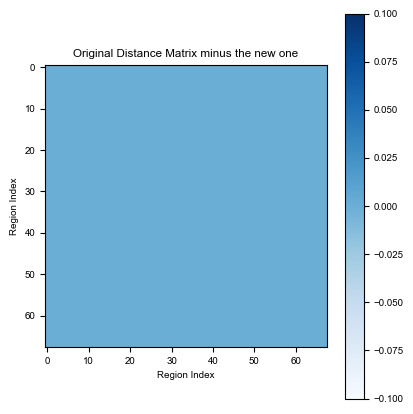

In [ ]:
dist_mat = np.array(dist_mat, dtype=float)
dist_mat_new = (dist_mat + dist_mat.T) / 2
dist_mat_new[np.diag_indices_from(dist_mat_new)] = 0.0
tiny = 1e-6
off = ~np.eye(dist_mat_new.shape[0], dtype=bool)
dist_mat_new[off] = np.maximum(dist_mat_new[off], tiny)

# Plotting the difference between the original and new distance matrix
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(dist_mat-dist_mat_new, cmap='Blues')
plt.colorbar()
plt.title("Original Distance Matrix minus the new one")
plt.xlabel("Region Index")
plt.ylabel("Region Index")  

# >> MATRICES ARE THE SAME; NO NEED TO REPLACE DISTANCE MATRIX

In [ ]:
# get data from 70 subjects

# Open the MAT-file as an HDF5 container. Loading with "sio.loadmat" does not work here, as the matlab version is too new (v7.3+).
import h5py

with h5py.File("/Users/adrian/Documents/01_projects/14_4D_lab/neonatal_generative_network_modeling-main/data/preprocessed/data_700mb/SC_68.mat", "r") as f:
    all_connectomes = np.array(f["M"])
    print("Data shape:", all_connectomes.shape) # (68, 68, 70) -> 68 regions, 68 regions, 70 subjects

Keys in file: ['M']
Data shape: (68, 68, 70)


Shape of one connectome: (68, 68)


Text(0, 0.5, 'Region Index')

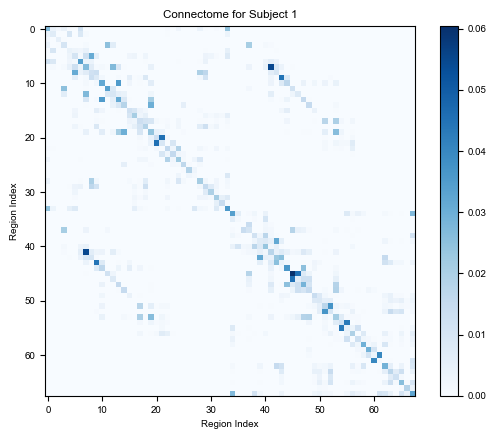

In [26]:
# Get one of the subjects' connectomes, and run "echoes" on it
# https://github.com/fabridamicelli/echoes

one_connectome = all_connectomes[:, :, 0]  # Get the first subject's connectome
print("Shape of one connectome:", one_connectome.shape)  # Should be (68
plt.imshow(one_connectome, cmap='Blues')
plt.colorbar()
plt.title("Connectome for Subject 1")
plt.xlabel("Region Index")
plt.ylabel("Region Index")


In [62]:
# Conn2res

# from conn2res import connectivity  # reservoir, readouts,
from conn2res import api 

# Example: Create a reservoir with the connectome
conn_1 = api.connectivity.Connectivity(w=one_connectome) # potentially density - but this is not currently checked for CONNECTEDNESS during the process. I am not doing that either, yet?
# Create a reservoir with the connectome
# reservoir.Reservoir(w=one_connectome) # _state: reservoir activation states 
# esn = reservoir.ESN(
#     w=conn_1, # or use one_connectome directly? 
#     # _state, n_nodes, 
#     activation_function="tanh",  # Activation function for the reservoir
# ) # source code for simulate() and set_activation_function() 



ModuleNotFoundError: No module named 'conn2res'

In [154]:
import numpy as np
import networkx as nx
import pandas as pd
from networkx.algorithms import community as nx_comm
from scipy.linalg import expm

def _avg_offdiag(M):
    n = M.shape[0]
    Md = M.copy()
    np.fill_diagonal(Md, 0.0)
    return Md.sum() / (n*(n-1))


def _largest_component_char_path_length(G):
    """Characteristic path length on the largest connected component (NaN if <2 nodes)."""
    if G.number_of_nodes() == 0:
        return np.nan
    # Pick largest connected component
    components = list(nx.connected_components(G))
    if not components:
        return np.nan
    H = G.subgraph(max(components, key=len)).copy()
    if H.number_of_nodes() < 2:
        return np.nan
    return nx.average_shortest_path_length(H)

def _get_rich_nodes(G, rich_nodes=None, top_percent=0.20):
    """
    Return a set of 'rich' nodes.
    - If rich_nodes provided (iterable of node indices), use that.
    - Else pick top `top_percent` by degree (ties broken arbitrarily).
    """
    if rich_nodes is not None:
        return set(rich_nodes)
    # default: top X% by degree
    deg = dict(G.degree())
    if len(deg) == 0:
        return set()
    k = max(1, int(np.ceil(top_percent * len(deg))))
    # sort nodes by degree descending and take top k
    sorted_nodes = sorted(deg.items(), key=lambda kv: kv[1], reverse=True)
    return set(n for n, _ in sorted_nodes[:k])

def _communicability(A_bin, mode="estrada_scaled", beta=None, t=1.0):
    """
    Compute average off-diagonal communicability in three modes:
      - estrada:        average of expm(A)
      - estrada_scaled: average of expm(b * A) with b = 1/max(1, λ_max)
      - heat:           average of exp(-t * L_norm) (heat kernel)
    Uses eigen-decomposition for the ‘estrada*’ modes to avoid expm overflows.
    """
    n = A_bin.shape[0]
    # Helper to average off-diagonal entries
    def avg_offdiag(M):
        np.fill_diagonal(M, 0.0)
        return M.sum() / (n*(n-1))

    if mode in ("estrada", "estrada_scaled"):
        # Compute symmetric A
        A = (A_bin + A_bin.T) / 2.0
        # Eigen-decompose once
        eigvals, eigvecs = np.linalg.eigh(A)
        # Determine scaling β
        if mode == "estrada":
            b = 1.0
        else:
            lam_max = np.max(eigvals)
            b = 1.0 / max(1.0, lam_max) if beta is None else beta
        # Exponentiate eigenvalues
        exp_eigs = np.exp(b * eigvals)
        # Reconstruct exp(b A) = V diag(exp(bλ)) V^T
        C = (eigvecs * exp_eigs) @ eigvecs.T
        return avg_offdiag(C)

    elif mode == "heat":
        # Normalized Laplacian L = I - D^{-1/2} A D^{-1/2}
        deg = A_bin.sum(axis=1)
        inv_sqrt = 1.0 / np.sqrt(np.maximum(deg, 1e-12))
        S = np.diag(inv_sqrt)
        L = np.eye(n) - S @ A_bin @ S
        # You can safely call expm here because L's spectrum lies in [0,2]
        from scipy.linalg import expm
        C = expm(-t * L)
        return avg_offdiag(C)

    else:
        raise ValueError("mode must be 'estrada', 'estrada_scaled', or 'heat'.")



def analyze_connectomes(connectomes, distance_matrix,
                        comm_mode="estrada_scaled", beta=None, t=1.0, 
                        rich_nodes_global=None, rich_top_percent=0.20):
    """
    connectomes: either list of (n,n) arrays OR array of shape (k,n,n) or (n,n,k)
    distance_matrix: (n,n) Euclidean distances
    comm_mode: 'estrada' | 'estrada_scaled' | 'heat'
    rich_nodes_global: optional iterable of node indices (same for all nets).
                       If None, uses top `rich_top_percent` by degree per-network.
    rich_top_percent: fraction used when rich_nodes_global is None.
    """
    # Normalize input shape to (k, n, n)
    arr = np.asarray(connectomes)
    if arr.ndim == 2:              # single connectome
        arr = arr[None, ...]       # (1, n, n)
    elif arr.ndim == 3:
        # if (n,n,k), move axes to (k,n,n)
        if arr.shape[0] == arr.shape[1]:
            arr = np.transpose(arr, (2, 0, 1))
        # else assume already (k,n,n)
    else:
        raise ValueError("connectomes must be (n,n), (k,n,n), or (n,n,k).")

    k, n, _ = arr.shape
    if distance_matrix.shape != (n, n):
        raise ValueError(f"distance_matrix must be {(n,n)}, got {distance_matrix.shape}")

    out = []
    for idx in range(k):
        A = np.array(arr[idx], dtype=float)
        # Ensure symmetry & zero diagonal
        A = np.maximum(A, A.T)
        np.fill_diagonal(A, 0.0)

        # Binary graph for global metrics
        A_bin = (A != 0).astype(float)
        G = nx.from_numpy_array(A_bin)

        # 1) Communicability (chosen mode)
        avg_comm = _communicability(A_bin, mode=comm_mode, beta=beta, t=t)

        # 2) Global efficiency
        glob_eff = nx.global_efficiency(G)

        # 3) Modularity (greedy)
        comms = list(nx_comm.greedy_modularity_communities(G))
        modu = nx_comm.modularity(G, comms) if len(comms) > 1 else 0.0 # is if statement ok? 

        # 4) Other global properties
        avg_clust = nx.average_clustering(G) if G.number_of_nodes() > 0 else np.nan # is if statment ok?
        avg_deg = float(np.mean([d for _, d in G.degree()])) if G.number_of_nodes() > 0 else np.nan # is if statment ok?
        trans = nx.transitivity(G) if G.number_of_nodes() > 0 else np.nan # is if statment ok?

        # 5) Average edge distance
        edge_d = [distance_matrix[i, j] for i, j in G.edges()]
        avg_dist = float(np.mean(edge_d)) if edge_d else np.nan

        # 6) Characteristic path length (largest CC)
        cpl = _largest_component_char_path_length(G)

        # 7) Rich-club measures
        rich_nodes = _get_rich_nodes(G, rich_nodes_global, top_percent=rich_top_percent)
        rich_edges = [(u, v) for (u, v) in G.edges() if u in rich_nodes and v in rich_nodes]
        n_rich_edges = len(rich_edges)
        rc_lengths = [distance_matrix[u, v] for (u, v) in rich_edges]
        avg_rc_length = float(np.mean(rc_lengths)) if rc_lengths else np.nan

        out.append({
            "network_index": idx,
            "avg_communicability": avg_comm,
            "global_efficiency": glob_eff,
            "modularity": modu,
            "avg_clustering": avg_clust,
            "avg_degree": avg_deg,
            "transitivity": trans,
            "avg_edge_distance": avg_dist,
            "char_path_length": cpl,
            "richclub_n_edges": n_rich_edges,
            "richclub_avg_length": avg_rc_length,
        })

    return pd.DataFrame(out)

# Calculate graph measures for all connectomes
graph_measures_df = analyze_connectomes(all_connectomes, dist_mat, comm_mode="estrada_scaled")  # This one is more numerically stable (at least for smaller connectomes), as it produces less extreme values.
# df = analyze_connectomes(all_connectomes, dist_mat, comm_mode="estrada") # This one is less stable, but follows BCT's communicability_bin behavior more closely.
pd.DataFrame.to_csv(graph_measures_df, OUTPUT_PATH + "/graph_measures_df.csv")
graph_measures_df

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_6931/4119552479.py:72: RuntimeWarning: divide by zero encountered in matmul
  C = (eigvecs * exp_eigs) @ eigvecs.T
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_6931/4119552479.py:72: RuntimeWarning: overflow encountered in matmul
  C = (eigvecs * exp_eigs) @ eigvecs.T
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_6931/4119552479.py:72: RuntimeWarning: invalid value encountered in matmul
  C = (eigvecs * exp_eigs) @ eigvecs.T


,network_index,avg_communicability,global_efficiency,modularity,avg_clustering,avg_degree,transitivity,avg_edge_distance,char_path_length,richclub_n_edges,richclub_avg_length
0,0,0.021013,0.597198,0.307704,0.610804,16.470588,0.513818,0.005878,1.911326,56,0.007240
1,1,0.021570,0.637913,0.215782,0.601557,19.529412,0.508043,0.004954,1.755487,62,0.006179
2,2,0.020930,0.607002,0.341498,0.628308,17.205882,0.519266,0.005537,1.872256,70,0.004997
3,3,0.020660,0.635426,0.285663,0.650042,20.029412,0.545131,0.004863,1.785338,76,0.004916
4,4,0.021431,0.621086,0.293950,0.603201,18.588235,0.530460,0.005209,1.828358,68,0.004923
...,...,...,...,...,...,...,...,...,...,...,...
65,65,0.021095,0.621634,0.281932,0.601182,18.352941,0.507955,0.005279,1.818262,65,0.005305
66,66,0.020561,0.597381,0.341336,0.614537,16.500000,0.514720,0.005830,1.909131,63,0.005171
67,67,0.021183,0.613367,0.304807,0.607088,17.647059,0.514428,0.005425,1.846795,61,0.004781
68,68,0.021954,0.643986,0.245783,0.601241,20.441176,0.511276,0.004771,1.746708,63,0.005449


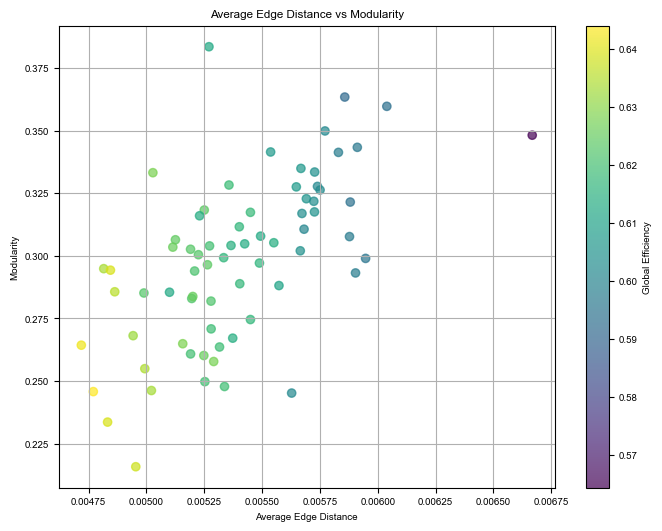

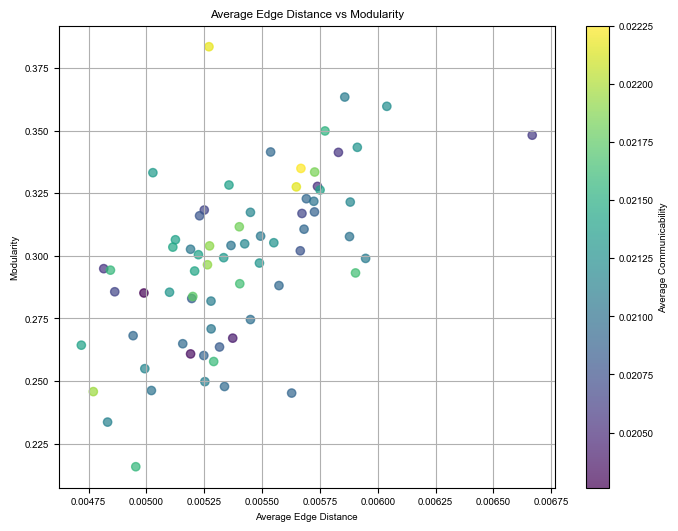

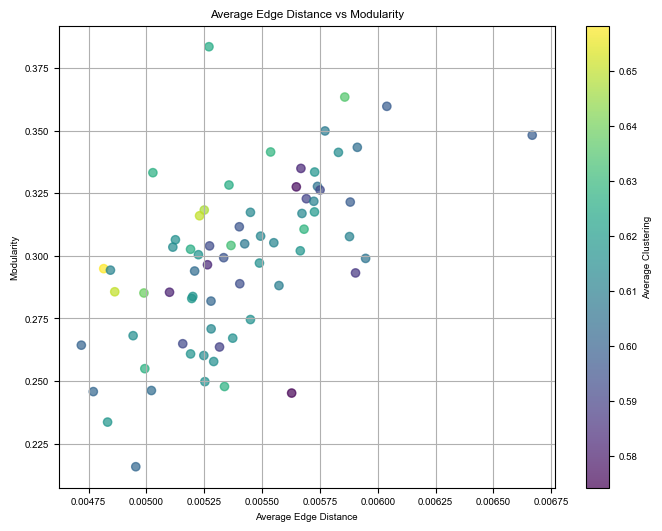

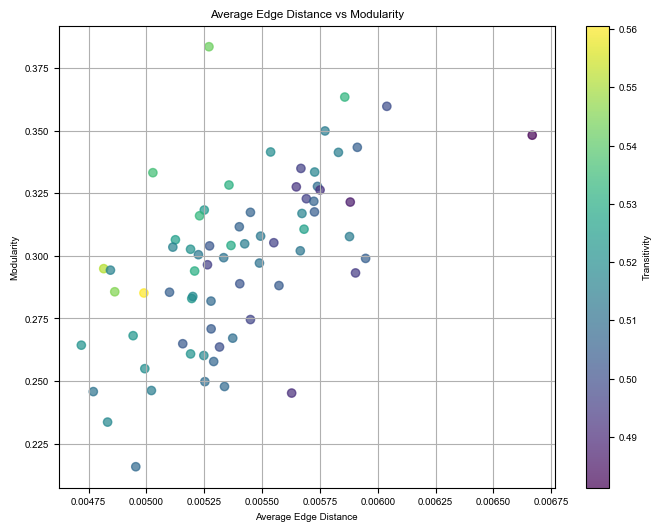

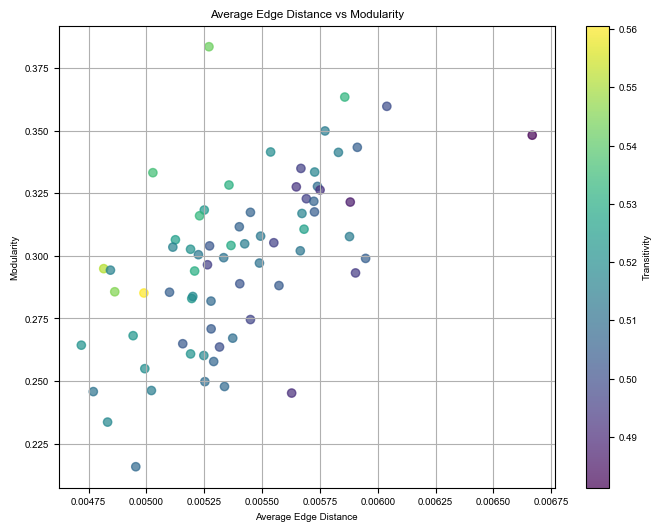

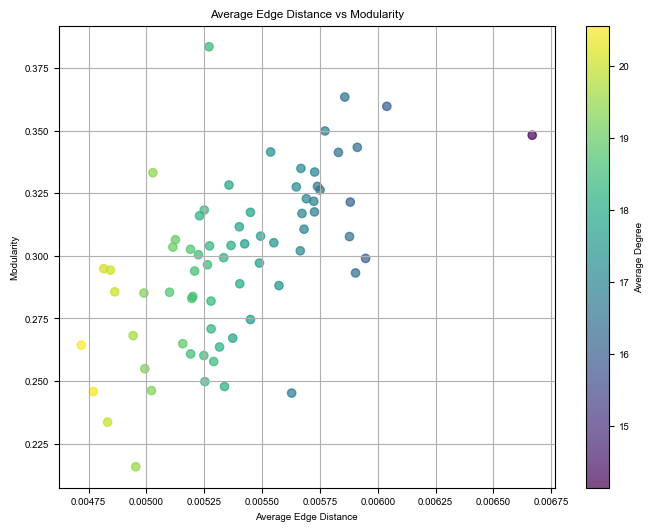

In [ ]:
# 2D scatterplots

df = graph_measures_df
# plt.figure(figsize=(6, 6))
# plt.scatter(df['avg_communicability'], df['global_efficiency'], alpha=0.7)
# plt.title('Average Communicability vs Global Efficiency')
# plt.xlabel('Average Communicability')
# plt.ylabel('Global Efficiency')
# plt.grid(True)
# plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(df['avg_edge_distance'], df['modularity'], c=df['global_efficiency'], alpha=0.7)
plt.title('Average Edge Distance vs Modularity')
plt.xlabel('Average Edge Distance')
plt.ylabel('Modularity')
plt.colorbar(label='Global Efficiency')
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(df['avg_edge_distance'], df['modularity'], c=df['avg_communicability'], alpha=0.7)
plt.title('Average Edge Distance vs Modularity')
plt.xlabel('Average Edge Distance')
plt.ylabel('Modularity')
plt.colorbar(label='Average Communicability')
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(df['avg_edge_distance'], df['modularity'], c=df['avg_clustering'], alpha=0.7)
plt.title('Average Edge Distance vs Modularity')
plt.xlabel('Average Edge Distance')
plt.ylabel('Modularity')
plt.colorbar(label='Average Clustering')
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(df['avg_edge_distance'], df['modularity'], c=df['transitivity'], alpha=0.7)
plt.title('Average Edge Distance vs Modularity')
plt.xlabel('Average Edge Distance')
plt.ylabel('Modularity')
plt.colorbar(label='Transitivity')
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(df['avg_edge_distance'], df['modularity'], c=df['transitivity'], alpha=0.7)
plt.title('Average Edge Distance vs Modularity')
plt.xlabel('Average Edge Distance')
plt.ylabel('Modularity')
plt.colorbar(label='Transitivity')
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(df['avg_edge_distance'], df['modularity'], c=df['avg_degree'], alpha=0.7)
plt.title('Average Edge Distance vs Modularity')
plt.xlabel('Average Edge Distance')
plt.ylabel('Modularity')
plt.colorbar(label='Average Degree')
plt.grid(True)
plt.show()

# plt.figure(figsize=(6, 6))
# # sort by avg_communicability
# plt.plot(df['avg_communicability'], alpha=0.7)
# plt.title('Average Communicability vs Global Efficiency')
# plt.xlabel('Average Communicability')
# plt.ylabel('Global Efficiency')
# plt.grid(True)
# plt.show()


# "network_index": idx,
#             "avg_communicability": avg_comm,
#             "global_efficiency": glob_eff,
#             "modularity": modu,
#             "avg_clustering": avg_clust,
#             "avg_degree": avg_deg,
#             "transitivity": trans,
#             "avg_edge_distance": avg_dist

In [ ]:
import numpy as np
import pandas as pd  # noqa: F401  # pandas is imported for completeness but not used directly
from typing import Iterable, List, Tuple, Dict
from echoes.esn import ESNRegressor
import time


def build_reservoir_from_connectome(
    connectome: np.ndarray,
    *,
    spectral_radius: float = 0.99,
    rank: bool = False,
    random_state: int | None = None,
) -> np.ndarray:
    """Construct a reservoir weight matrix from a binary connectome.

    Each non‑zero entry of the connectome is treated as a potential
    synapse.  We assign weights drawn from a uniform distribution in
    [-1, 1] to these edges and set all absent connections to zero.
    Self‑connections are removed.  Finally, the matrix is rescaled to
    have the desired spectral radius.

    Parameters
    ----------
    connectome : np.ndarray, shape (N, N)
        Binary or weighted adjacency matrix describing the reservoir
        topology.  Non‑zero entries indicate the presence of a synapse.
        The diagonal will be zeroed.
    spectral_radius : float, default 0.99
        Desired spectral radius of the reservoir weight matrix.  A
        spectral radius close to (but less than) one is typical for
        echo‑state networks and was used in Damicelli et al.
    rank : bool, default False
        If True, weights are assigned to preserve the rank order of the
        original weights (Bio (rank) condition).  If False, weights are
        assigned arbitrarily (Bio (no‑rank)).
    random_state : int or None, default None
        Seed for the pseudo‑random number generator.  Use this to make
        the weight initialisation reproducible.

    Returns
    -------
    W : np.ndarray, shape (N, N)
        Reservoir weight matrix whose non‑zero pattern matches the
        connectome.
    """
    rng = np.random.default_rng(random_state)
    # Create a mask of existing edges (True where connectome has
    # connections)
    mask = connectome.astype(bool)
    # Random weights for present edges
    random_weights = rng.uniform(-1.0, 1.0, size=connectome.shape)
    # Optionally rank‑order the random weights according to the
    # connectome’s original weights
    if rank:
        # Flatten both arrays, obtain sort order of original weights and
        # assign random values accordingly
        orig = connectome.flatten()
        rand = random_weights.flatten()
        # Get indices of non‑zero weights in descending order
        nz_indices = np.where(mask.flatten())[0]
        # Sort original weights to get rank order (descending)
        rank_order = nz_indices[np.argsort(-orig[nz_indices])]
        # Sort random values (descending) for assignment
        rand_sorted = np.sort(rand[nz_indices])[::-1]
        # Create weight matrix filled with zeros
        W = np.zeros_like(connectome, dtype=float)
        for idx, rand_val in zip(rank_order, rand_sorted):
            W.flat[idx] = rand_val
    else:
        W = random_weights * mask
    # Remove self‑connections
    np.fill_diagonal(W, 0.0)
    # Rescale spectral radius if necessary
    # Estimate largest eigenvalue magnitude using power iteration
    def _spectral_radius(matrix: np.ndarray, iterations: int = 100) -> float:
        vec = rng.normal(size=(matrix.shape[0],))
        vec /= np.linalg.norm(vec)
        for _ in range(iterations):
            vec = matrix @ vec
            norm = np.linalg.norm(vec)
            vec /= norm
        # Rayleigh quotient approximation
        return float(np.linalg.norm(matrix @ vec) / np.linalg.norm(vec))
    current_rho = _spectral_radius(W)
    if current_rho > 0:
        W *= spectral_radius / current_rho
    return W

def _generate_mc_dataset(
    train_len: int,
    test_len: int,
    n_lags: int,
    rng: np.random.Generator,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Generate data for the memory capacity task.

    A random univariate input sequence X is generated and the target
    consists of delayed versions of X for each lag in `1..n_lags`.
    Training and testing sequences are drawn sequentially from a single
    long sequence to avoid boundary effects, and an initial transient
    segment is left in front of the training data.

    Parameters
    ----------
    train_len : int
        Length of the training sequence.
    test_len : int
        Length of the testing sequence.
    n_lags : int
        Number of delayed outputs to generate.
    rng : np.random.Generator
        Random number generator instance.

    Returns
    -------
    X_train : np.ndarray, shape (train_len, 1)
        Input training sequence.
    Y_train : np.ndarray, shape (train_len, n_lags)
        Training targets; column ``i`` is the input delayed by
        ``i+1`` time steps.
    X_test : np.ndarray, shape (test_len, 1)
        Input testing sequence.
    Y_test : np.ndarray, shape (test_len, n_lags)
        Testing targets.
    """
    total_len = train_len + test_len + n_lags + 100  # extra for lagging and transient
    seq = rng.uniform(0.0, 1.0, size=(total_len,))
    # Create delayed targets
    def build_targets(x: np.ndarray, lags: int) -> np.ndarray:
        T = len(x) - lags
        targets = np.zeros((T, lags), dtype=float)
        for i in range(lags):
            targets[:, i] = x[lags - (i + 1) : - (i + 1) if i + 1 > 0 else None]
        return targets
    Y_full = build_targets(seq, n_lags)
    # Discard initial transient and split
    start_train = 100  # discard first 100 samples (transient)
    end_train = start_train + train_len
    X_train = seq[start_train : end_train].reshape(-1, 1)
    Y_train = Y_full[start_train : end_train]
    X_test = seq[end_train : end_train + test_len].reshape(-1, 1)
    Y_test = Y_full[end_train : end_train + test_len]
    return X_train, Y_train, X_test, Y_test

def evaluate_memory_capacity(
    W: np.ndarray,
    *,
    n_lags: int = 50,
    train_len: int = 4000,
    test_len: int = 1000,
    n_runs: int = 10,
    spectral_radius: float | None = None,
    random_state: int | None = None,
) -> Dict[str, float]:
    """Evaluate the memory capacity of an ESN with a given reservoir.

    For each run, a new input/output sequence is generated and the ESN
    is reinitialised.  The memory capacity is computed as the sum of
    squared Pearson correlation coefficients between each delayed
    output and its target across the test set.  The final result
    aggregates the mean and standard deviation over runs.

    Parameters
    ----------
    W : np.ndarray, shape (N, N)
        Reservoir weight matrix.
    n_lags : int, default 50
        Number of delays to include in the target.  The original
        article sums correlations up to lag 200; adjust as needed.
    train_len : int, default 4000
        Number of time steps for training.
    test_len : int, default 1000
        Number of time steps for testing.
    n_runs : int, default 10
        Number of independent runs to average over.  Each run uses a
        freshly generated input sequence and randomly initialised
        input weights.
    spectral_radius : float or None, default None
        Optional spectral radius to override the rescaling performed in
        ``build_reservoir_from_connectome``.  Pass ``None`` to use the
        existing scaling of ``W``.
    random_state : int or None, default None
        Seed controlling both the data generation and the ESN’s input
        weights.  Different runs will still be independent because the
        seed is advanced internally.

    Returns
    -------
    results : dict
        Dictionary containing the mean and standard deviation of the
        memory capacity across runs.  Keys are ``"mc_mean"`` and
        ``"mc_std"``.
    """
    rng = np.random.default_rng(random_state)
    mc_values: List[float] = []
    for _ in range(n_runs):
        # Generate dataset
        X_tr, Y_tr, X_te, Y_te = _generate_mc_dataset(train_len, test_len, n_lags, rng)
        # Instantiate ESN
        esn = ESNRegressor(
            W=W.copy(),
            spectral_radius=spectral_radius if spectral_radius is not None else 1.0,
            n_transient=0,
            input_scaling=1.0,
            leak_rate=1.0,
            bias=1.0,
            regression_method="pinv",
        )
        # Fit on training data
        esn.fit(X_tr, Y_tr)
        # Predict on test data
        Y_pred = esn.predict(X_te)
        # Compute squared Pearson correlations for each lag
        mc = 0.0
        for col in range(n_lags):
            y_true = Y_te[:, col]
            y_hat = Y_pred[:, col]
            # Compute Pearson correlation
            if np.std(y_true) == 0 or np.std(y_hat) == 0:
                corr = 0.0
            else:
                corr = np.corrcoef(y_true, y_hat)[0, 1]
            mc += corr ** 2
        mc_values.append(mc)
    return {
        "mc_mean": float(np.mean(mc_values)),
        "mc_std": float(np.std(mc_values)),
    }

def _generate_sequence_recall_dataset(
    L: int,
    n_trials: int,
    rng: np.random.Generator,
) -> Tuple[np.ndarray, np.ndarray, List[int]]:
    """Generate data for the sequence recall task.

    Each trial consists of a fixation phase of length ``L`` during
    which a random pattern of ``L`` numbers (uniformly drawn from
    [0, 1]) is presented via the first input channel while the recall
    channel is zero.  In the subsequent recall phase of length ``L``
    the recall channel is set to one and the network must reproduce
    the memorised pattern on its single output.  The second input
    channel is otherwise zero.  The target is zero during fixation
    (no recall) and equal to the pattern during recall.  All trials
    are concatenated into a single sequence for training or testing.

    Parameters
    ----------
    L : int
        Pattern length; also controls trial duration (2*L steps).
    n_trials : int
        Number of independent trials to generate.
    rng : np.random.Generator
        Random number generator.

    Returns
    -------
    X : np.ndarray, shape (n_trials * 2*L, 2)
        Input matrix.  Column 0 carries the pattern, column 1 the
        recall cue.
    Y : np.ndarray, shape (n_trials * 2*L, 1)
        Target output.
    recall_indices : list of int
        Indices of the time steps corresponding to the recall phase.
        These indices are used to compute the performance metric.
    """
    X_list: List[np.ndarray] = []
    Y_list: List[np.ndarray] = []
    recall_indices: List[int] = []
    idx_offset = 0
    for _ in range(n_trials):
        pattern = rng.uniform(0.0, 1.0, size=L)
        # Fixation phase
        X_fix = np.zeros((L, 2), dtype=float)
        X_fix[:, 0] = pattern  # pattern presented on first input
        Y_fix = np.zeros((L, 1), dtype=float)
        # Recall phase
        X_rec = np.zeros((L, 2), dtype=float)
        X_rec[:, 1] = 1.0  # recall cue on second input
        Y_rec = pattern.reshape(-1, 1)
        X_trial = np.vstack([X_fix, X_rec])
        Y_trial = np.vstack([Y_fix, Y_rec])
        X_list.append(X_trial)
        Y_list.append(Y_trial)
        # Record recall indices (offset from start of sequence)
        recall_indices.extend(list(range(idx_offset + L, idx_offset + 2 * L)))
        idx_offset += 2 * L
    X = np.vstack(X_list)
    Y = np.vstack(Y_list)
    return X, Y, recall_indices

def evaluate_sequence_recall(
    W: np.ndarray,
    *,
    pattern_lengths: Iterable[int] = range(5, 26),
    train_trials: int = 800,
    test_trials: int = 200,
    n_runs: int = 5,
    spectral_radius: float | None = None,
    random_state: int | None = None,
) -> Dict[int, Dict[str, float]]:
    """Evaluate sequence recall performance for multiple pattern lengths.

    For each pattern length in ``pattern_lengths`` and each run, an
    independent dataset is generated and the ESN is reinitialised.
    Performance is measured by the coefficient of determination (R²)
    between the predicted and true outputs, computed over the recall
    period only.  Results are aggregated by pattern length.

    Parameters
    ----------
    W : np.ndarray, shape (N, N)
        Reservoir weight matrix.
    pattern_lengths : iterable of int, default range(5, 26)
        Pattern lengths (task difficulties) to evaluate.
    train_trials : int, default 800
        Number of trials for training per run.
    test_trials : int, default 200
        Number of trials for testing per run.
    n_runs : int, default 5
        Number of independent runs per pattern length.
    spectral_radius : float or None, default None
        Optional spectral radius to override the scaling of ``W``.
    random_state : int or None, default None
        Seed controlling the data generation and input weight initialisation.

    Returns
    -------
    results : dict
        Mapping from pattern length to a dictionary with keys
        ``"r2_mean"`` and ``"r2_std"`` representing the average R²
        across runs and its standard deviation.
    """
    rng = np.random.default_rng(random_state)
    results: Dict[int, Dict[str, float]] = {}
    for L in pattern_lengths:
        r2_values: List[float] = []
        for _ in range(n_runs):
            # Generate dataset
            X_tr, Y_tr, recall_idx_tr = _generate_sequence_recall_dataset(L, train_trials, rng)
            X_te, Y_te, recall_idx_te = _generate_sequence_recall_dataset(L, test_trials, rng)
            # Instantiate ESN
            esn = ESNRegressor(
                W=W.copy(),
                spectral_radius=spectral_radius if spectral_radius is not None else 1.0,
                n_transient=0,
                input_scaling=1.0,
                leak_rate=1.0,
                bias=1.0,
                regression_method="pinv",
            )
            # Fit and predict
            esn.fit(X_tr, Y_tr)
            Y_pred = esn.predict(X_te)
            # Evaluate R² on recall period only
            y_true = Y_te[recall_idx_te, 0]
            y_hat = Y_pred[recall_idx_te, 0]
            # Compute R² manually
            ss_res = np.sum((y_true - y_hat) ** 2)
            ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
            r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else 0.0
            r2_values.append(r2)
        results[L] = {
            "r2_mean": float(np.mean(r2_values)),
            "r2_std": float(np.std(r2_values)),
        }
    return results




In [82]:
import time
# Iterate over subjects and compute memory capacity and sequence recall
results = []
durations = []
for i in range(all_connectomes.shape[2]):
    A = all_connectomes[:, :, i]
    print(f"Processing network_index {i}. Total number connectomes: {all_connectomes.shape[2]}...")

    start_time = time.time()
    W = build_reservoir_from_connectome(A, spectral_radius=0.99, rank=False)
    time_building_reservoir = time.time() - start_time

    mc = evaluate_memory_capacity(W, n_lags=50, train_len=4000, test_len=1000,
                                    n_runs=10, random_state=i)
    time_evaluating_mc = time.time() - start_time - time_building_reservoir

    seq = evaluate_sequence_recall(W, pattern_lengths=range(5, 26),
                                    train_trials=800, test_trials=200,
                                    n_runs=5, random_state=i)
    time_evaluating_seq_recall = time.time() - start_time - time_building_reservoir - time_evaluating_mc

    # Store results for this subject
    results.append({
        "network_index": i, 
        "memory_capacity": mc,
        "sequence_recall": seq
    })
    # Store durations for each step
    durations.append({
        "subject": i,
        "time_building_reservoir": time_building_reservoir,
        "time_evaluating_mc": time_evaluating_mc,
        "time_evaluating_seq_recall": time_evaluating_seq_recall,
    })
    break
# Do something with results (e.g. save to CSV)

Processing network_index 0. Total number connectomes: 70...


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_6931/1203032838.py:80: RuntimeWarning: divide by zero encountered in matmul
  vec = matrix @ vec
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_6931/1203032838.py:80: RuntimeWarning: overflow encountered in matmul
  vec = matrix @ vec
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_6931/1203032838.py:80: RuntimeWarning: invalid value encountered in matmul
  vec = matrix @ vec
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_6931/1203032838.py:84: RuntimeWarning: divide by zero encountered in matmul
  return float(np.linalg.norm(matrix @ vec) / np.linalg.norm(vec))
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_6931/1203032838.py:84: RuntimeWarning: overflow encountered in matmul
  return float(np.linalg.norm(matrix @ vec) / np.linalg.norm(vec))
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_6931/1203032838.py:84: RuntimeWarning: invalid value encountered in matmul
  retur

In [83]:
results

[{'network_index': 0,
  'memory_capacity': {'mc_mean': 1.0430725445718112,
   'mc_std': 0.009231735655080783},
  'sequence_recall': {5: {'r2_mean': 0.9129229711515754,
    'r2_std': 0.023143668756552844},
   6: {'r2_mean': 0.6185943584349353, 'r2_std': 0.11926431503471177},
   7: {'r2_mean': 0.30052458448435326, 'r2_std': 0.14908484158968824},
   8: {'r2_mean': 0.054179954129624106, 'r2_std': 0.037122868089417796},
   9: {'r2_mean': 0.014308198493685476, 'r2_std': 0.012569009367706309},
   10: {'r2_mean': 0.0004892940109705313, 'r2_std': 0.0030212840642751806},
   11: {'r2_mean': 0.00025059558473554676, 'r2_std': 0.0040279974459554915},
   12: {'r2_mean': -0.002520652369849774, 'r2_std': 0.0014623485458543268},
   13: {'r2_mean': -0.0037934532511715523, 'r2_std': 0.001073227498840497},
   14: {'r2_mean': -0.0020720742219486167, 'r2_std': 0.0017018997564559179},
   15: {'r2_mean': -0.0030223982612863852, 'r2_std': 0.0011735316203971325},
   16: {'r2_mean': -0.0019322826119935854, 'r2_st

In [84]:
esn_results_df = pd.DataFrame(results)
esn_results_df.to_csv("esn_results.csv", index=False)

In [85]:
# combine graph_measures_df and esn_results_df
combined_df = pd.merge(graph_measures_df, esn_results_df, on="network_index")
combined_df

,network_index,avg_communicability,global_efficiency,modularity,avg_clustering,avg_degree,transitivity,avg_edge_distance,memory_capacity,sequence_recall
0,0,0.021013,0.597198,0.307704,0.610804,16.470588,0.513818,0.005878,"{'mc_mean': 1.0430725445718112, 'mc_std': 0.00...","{5: {'r2_mean': 0.9129229711515754, 'r2_std': ..."


In [ ]:
import numpy as np
import pandas as pd
import networkx as nx
from scipy.stats import ks_2samp
from numpy.random import default_rng

# ----------  Energy calculation (Mousley et al.)  ---------- #

def gnm_energy(A_obs, A_sim, dist_mat):
    """
    Compute energy = max(KS_degree, KS_clustering, KS_betweenness, KS_edge_length).
    A_obs and A_sim must be binary and undirected.
    """
    def prep(A):
        A_bin = (A > 0).astype(int)
        A_bin = np.triu(A_bin, k=1)
        return A_bin + A_bin.T

    # binarize, ensure symmetry & zero diagonal
    B_obs = prep(A_obs)
    B_sim = prep(A_sim)

    G_obs = nx.from_numpy_array(B_obs)
    G_sim = nx.from_numpy_array(B_sim)

    # Degree
    deg_obs = np.array([d for _, d in G_obs.degree()])
    deg_sim = np.array([d for _, d in G_sim.degree()])
    ks_degree = ks_2samp(deg_obs, deg_sim).statistic

    # Clustering coefficient
    cc_obs = np.array(list(nx.clustering(G_obs).values()))
    cc_sim = np.array(list(nx.clustering(G_sim).values()))
    ks_cc = ks_2samp(cc_obs, cc_sim).statistic

    # Betweenness centrality
    bc_obs = np.array(list(nx.betweenness_centrality(G_obs, normalized=True).values()))
    bc_sim = np.array(list(nx.betweenness_centrality(G_sim, normalized=True).values()))
    ks_bc = ks_2samp(bc_obs, bc_sim).statistic

    # Edge length distributions (using Euclidean distance matrix)
    def edge_lengths(G):
        return np.array([dist_mat[i, j] for i, j in G.edges()])
    el_obs = edge_lengths(G_obs)
    el_sim = edge_lengths(G_sim)
    ks_el = ks_2samp(el_obs, el_sim).statistic

    energy = max(ks_degree, ks_cc, ks_bc, ks_el)
    return energy


# ----------  GNM simulation  ---------- #

def compute_homophily_matrix(A):
    A = (A > 0).astype(int)
    shared = A @ A
    deg = A.sum(axis=1)
    denom = deg[:, None] + deg[None, :] - shared
    with np.errstate(divide='ignore', invalid='ignore'):
        k = np.where(denom > 0, shared / denom, 0.0)
    np.fill_diagonal(k, 0.0)
    return k

def generate_gnm(A_seed, target_m, dist_mat, gamma, eta, rng=None, eps=1e-12):
    """
    Grow until A has target_m undirected edges.
    P(i,j) ∝ (d_ij)**eta * (k_ij)**gamma, with eps-stabilization.
    """
    rng = np.random.default_rng() if rng is None else rng
    A = A_seed.copy().astype(float)
    n = A.shape[0]

    # Distance term: guard against zeros & negatives
    D = np.array(dist_mat, dtype=float)
    D = np.maximum(D, eps)         # avoid 0**negative
    np.fill_diagonal(D, np.inf)    # never consider self-edges
    with np.errstate(over='ignore'):
        cost_term = D ** eta       # finite because D>=eps

    while (A.sum() // 2) < target_m:
        # Recompute homophily each step
        k_mat = compute_homophily_matrix((A > 0).astype(int))
        k_safe = np.maximum(k_mat, eps)  # avoid 0**negative
        with np.errstate(over='ignore'):
            value_term = k_safe ** gamma

        # Candidate edges: only absent upper-triangular
        mask = np.triu((A == 0), k=1)
        prob = cost_term * value_term
        prob = prob * mask

        # Remove non-finite junk
        prob[~np.isfinite(prob)] = 0.0
        total = prob.sum()

        if total <= 0:
            # uniform fallback among missing edges
            cand = np.argwhere(mask)
            i, j = cand[rng.integers(0, len(cand))]
        else:
            cand = np.argwhere(mask)
            p_flat = prob[mask].ravel()
            p_flat = p_flat / p_flat.sum()  # renormalize
            i, j = cand[rng.choice(len(cand), p=p_flat)]

        A[i, j] = 1.0
        A[j, i] = 1.0

    return A


# ----------  Binarization for edges  ---------- # Needed for GNM fitting
def _binarize_for_edges(A, thr=0.0):
    A = np.asarray(A, float)
    A = (A + A.T) / 2.0
    np.fill_diagonal(A, 0.0)
    A_bin = (A > thr).astype(int)   # set your threshold here
    return A_bin

# ----------  Grid search + evaluation per subject  ---------- #

def fit_gnm_for_subject(A_obs, dist_mat, wide_eta=(-8, 0), wide_gamma=(-8, 8),
                        wide_grid=10, narrow_eta=(-3, 0), narrow_gamma=(0.1, 0.6),
                        narrow_grid=10, sample_probability=0.1, rng=None):
    """
    For one subject, perform a wide and narrow grid search to find the best (eta, gamma),
    optionally sampling some generated networks to run ESN analysis immediately.
    
    Returns:
      best_params: dict with gamma, eta, energy.
      sampled_models: list of (A_sim, eta, gamma) randomly chosen according to sample_probability.
      energy_grid: DataFrame with columns ['eta', 'gamma', 'energy'] from the narrow search.
    """
    rng = default_rng() if rng is None else rng

    n = A_obs.shape[0]
    # m_edges = int(A_obs.sum() // 2)
    
    A_bin = _binarize_for_edges(A_obs, thr=0.0)  # or pick a real threshold
    m_edges = int(np.triu(A_bin, k=1).sum())

    # Prepare seed network: 10% density network as in Mousley et al. (or use your own)
    # Here we use the union of edges present in >95% of all subjects; you can compute
    # this prior to looping over subjects. For simplicity we start with an empty seed.
    A_seed = np.zeros_like(A_obs)

    # Wide grid to estimate good region (coarse)
    wide_eta_values = np.linspace(wide_eta[0], wide_eta[1], wide_grid)
    wide_gamma_values = np.linspace(wide_gamma[0], wide_gamma[1], wide_grid)
    energies_wide = []
    for eta in wide_eta_values:
        for gamma in wide_gamma_values:
            A_sim = generate_gnm(A_seed, m_edges, dist_mat, gamma, eta, rng)
            energy = gnm_energy(A_obs, A_sim, dist_mat)
            energies_wide.append((eta, gamma, energy))
    # Identify roughly best region
    energies_wide = np.array(energies_wide, dtype=[('eta', float), ('gamma', float), ('energy', float)])
    best_eta_approx, best_gamma_approx = energies_wide['eta'][energies_wide['energy'].argmin()], \
                                         energies_wide['gamma'][energies_wide['energy'].argmin()]

    # Narrow grid around Mousley’s recommended range
    narrow_eta_values = np.linspace(narrow_eta[0], narrow_eta[1], narrow_grid)
    narrow_gamma_values = np.linspace(narrow_gamma[0], narrow_gamma[1], narrow_grid)
    energy_grid = []
    sampled_models = []
    best_energy = np.inf
    best_eta, best_gamma = None, None

    for eta in narrow_eta_values:
        for gamma in narrow_gamma_values:
            A_sim = generate_gnm(A_seed, m_edges, dist_mat, gamma, eta, rng)
            energy = gnm_energy(A_obs, A_sim, dist_mat)
            energy_grid.append({"eta": eta, "gamma": gamma, "energy": energy})
            # Keep track of best
            if energy < best_energy:
                best_energy = energy
                best_eta, best_gamma = eta, gamma
            # With some probability, save this network for later ESN analysis
            if rng.random() < sample_probability:
                sampled_models.append((A_sim.copy(), eta, gamma))

    energy_df = pd.DataFrame(energy_grid)
    best_params = {"eta": best_eta, "gamma": best_gamma, "energy": best_energy}
    return best_params, sampled_models, energy_df



# ----------  Full pipeline across subjects  ---------- #

def run_full_gnm_and_esn_pipeline(connectomes, dist_mat, sample_prob=0.1,
                                  n_sample_limit=100):
    """
    Run GNM fitting and ESN analysis. Performs grid search for each subject,
    collects best parameters and energy, then runs ESN analysis on a random
    subset of generated networks. Returns DataFrames with results.
    sample_prob controls how often to keep a generated GNM for ESN testing.
    """
    rng = default_rng(0)

    n_subj = connectomes.shape[2]
    best_param_rows = []
    energy_details = []
    sampled_networks = []

    # 1) Fit GNMs for all subjects and collect random samples
    for subj in range(n_subj):
        A_obs = connectomes[:, :, subj].copy()
        if A_obs.shape[0] != A_obs.shape[1]:
            raise ValueError(f"Connectome for subject {subj} is not square: {A_obs.shape}")
        best_params, samples, energy_grid = fit_gnm_for_subject(
            A_obs, dist_mat, wide_grid=3, narrow_grid=3, sample_probability=sample_prob, rng=rng) # wide_grid=10, narrow_eta=(-3, 0), narrow_gamma=(0.1, 0.6), narrow_grid=10, sample_probability=0.1, rng=None)
        
        best_param_rows.append({"network_index": subj,
                                "gamma": best_params["gamma"],
                                "eta": best_params["eta"],
                                "energy": best_params["energy"]})
        energy_grid["network_index"] = subj
        energy_details.append(energy_grid)
        # Add samples to global list
        for A_sim, eta, gamma in samples:
            sampled_networks.append({"A_sim": A_sim, "eta": eta, "gamma": gamma, "subject": subj})
        print(f"[Subj {subj}] best eta={best_params['eta']:.3f}, gamma={best_params['gamma']:.3f}, energy={best_params['energy']:.3f}")

    # Create DataFrames
    df_best = pd.DataFrame(best_param_rows)
    df_energy_details = pd.concat(energy_details, ignore_index=True)

    # 2) Sample networks for ESN analysis (limit total to n_sample_limit)
    rng.shuffle(sampled_networks)
    sampled_networks = sampled_networks[:n_sample_limit]
    esn_records = []

    for i, item in enumerate(sampled_networks):
        A_sim = item["A_sim"]
        subj_idx = item["subject"]
        eta = item["eta"]
        gamma = item["gamma"]
        # Build reservoir, evaluate memory capacity and sequence recall using your functions
        W = build_reservoir_from_connectome(A_sim, spectral_radius=0.99, rank=False)
        mc = evaluate_memory_capacity(W, n_lags=50, train_len=4000, test_len=1000,
                                      n_runs=10, random_state=i)
        seq = evaluate_sequence_recall(W, pattern_lengths=range(5, 26),
                                       train_trials=800, test_trials=200,
                                       n_runs=5, random_state=i)
        esn_records.append({
            "sample_index": i,
            "subject": subj_idx,
            "eta": eta,
            "gamma": gamma,
            "memory_capacity": mc,
            "sequence_recall": seq
        })
        # print(f"ESN sample {i}: subj={subj_idx}, eta={eta:.3f}, gamma={gamma:.3f}, MC={mc:.3f}, SR={seq:.3f}")

    df_esn = pd.DataFrame(esn_records)

    return df_best, df_energy_details, df_esn

# Example usage:
# connectomes: np.array shape (68, 68, 70)
# dist_mat: your (68,68) distance matrix
# df_best, df_energy_grids, df_esn = run_full_gnm_and_esn_pipeline(all_connectomes, dist_mat)

# Different numbers of connectomes: 
# less_connectomes = np.array([all_connectomes[:,:,0]]).T
less_connectomes = all_connectomes[:, :, :5]  # Use first 5 connectomes for testing
df_best, df_energy_grids, df_esn = run_full_gnm_and_esn_pipeline(less_connectomes, dist_mat)
# df_best.to_csv("gnm_best_params.csv", index=False)
# df_esn.to_csv("gnm_esn_results.csv", index=False)

# 5 in 1 minute. 

[Subj 0] best eta=0.000, gamma=0.600, energy=0.632
[Subj 1] best eta=0.000, gamma=0.350, energy=0.540
[Subj 2] best eta=0.000, gamma=0.350, energy=0.735
[Subj 3] best eta=-1.500, gamma=0.600, energy=0.706
[Subj 4] best eta=-3.000, gamma=0.600, energy=0.786


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_6931/1203032838.py:80: RuntimeWarning: divide by zero encountered in matmul
  vec = matrix @ vec
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_6931/1203032838.py:80: RuntimeWarning: overflow encountered in matmul
  vec = matrix @ vec
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_6931/1203032838.py:80: RuntimeWarning: invalid value encountered in matmul
  vec = matrix @ vec
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_6931/1203032838.py:84: RuntimeWarning: divide by zero encountered in matmul
  return float(np.linalg.norm(matrix @ vec) / np.linalg.norm(vec))
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_6931/1203032838.py:84: RuntimeWarning: overflow encountered in matmul
  return float(np.linalg.norm(matrix @ vec) / np.linalg.norm(vec))
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_6931/1203032838.py:84: RuntimeWarning: invalid value encountered in matmul
  retur

In [141]:
df_best

,network_index,gamma,eta,energy
0,0,0.60,0.0,0.632353
1,1,0.35,0.0,0.540347
2,2,0.35,0.0,0.735294
3,3,0.60,-1.5,0.705882
4,4,0.60,-3.0,0.786152


In [142]:
df_energy_grids

,eta,gamma,energy,network_index
0,-3.0,0.10,0.883929,0
1,-3.0,0.35,0.873214,0
2,-3.0,0.60,0.837500,0
3,-1.5,0.10,0.875000,0
4,-1.5,0.35,0.841071,0
5,-1.5,0.60,0.707143,0
6,0.0,0.10,0.867647,0
7,0.0,0.35,0.911765,0
8,0.0,0.60,0.632353,0
9,-3.0,0.10,0.788841,1


In [143]:
df_esn 

,sample_index,subject,eta,gamma,memory_capacity,sequence_recall
0,0,3,-1.5,0.10,"{'mc_mean': 1.042572008927359, 'mc_std': 0.009...","{5: {'r2_mean': 0.9095600260870865, 'r2_std': ..."
1,1,3,0.0,0.35,"{'mc_mean': 1.0469526183081364, 'mc_std': 0.00...","{5: {'r2_mean': 0.7199223272692634, 'r2_std': ..."
2,2,4,0.0,0.10,"{'mc_mean': 1.0423871172341754, 'mc_std': 0.01...","{5: {'r2_mean': 0.7913827091077713, 'r2_std': ..."
3,3,0,-3.0,0.60,"{'mc_mean': 1.051886428239495, 'mc_std': 0.010...","{5: {'r2_mean': 0.7570637787440282, 'r2_std': ..."


In [144]:

# Plotting 

import numpy as np
import matplotlib.pyplot as plt
from numpy.random import default_rng

def compute_energy_landscape(connectomes, dist_mat,
                             eta_range=(-3.0, 0.0), gamma_range=(0.1, 0.6),
                             grid_size=(100, 100), seed=0):
    """
    Compute a group energy landscape over an (eta, gamma) grid.
    For each grid cell we simulate ONE network for each subject and take the
    median energy across subjects (fast + smooth enough). Increase reps if needed.

    Returns
    -------
    etas, gammas : 1D arrays
    energy_grid  : (len(gammas), len(etas)) median energy across subjects
    """
    rng = default_rng(seed)
    n = connectomes.shape[0]
    m_subj = connectomes.shape[2]

    etas   = np.linspace(eta_range[0], eta_range[1], grid_size[0])
    gammas = np.linspace(gamma_range[0], gamma_range[1], grid_size[1])

    # target number of undirected edges per subject (match observed density)
    # target_m = [int(connectomes[:, :, s].sum() // 2) for s in range(m_subj)]
    target_m = []
    for s in range(m_subj):
        A_bin = _binarize_for_edges(connectomes[:, :, s], thr=0.0)  # or pick a real threshold
        m_edges = int(np.triu(A_bin, k=1).sum())
        target_m.append(m_edges)

    print(f"Target edges per subject: {target_m}")

    # start from empty seed (you can replace with a consensus 10% seed if you have it)
    A_seed = np.zeros((n, n), dtype=float)

    energy_grid = np.zeros((len(gammas), len(etas)), dtype=float)

    for gi, gamma in enumerate(gammas):
        for ei, eta in enumerate(etas):
            energies = []
            for s in range(m_subj):
                A_sim = generate_gnm(A_seed, target_m[s], dist_mat, gamma, eta, rng)
                E = gnm_energy(connectomes[:, :, s], A_sim, dist_mat)
                energies.append(E)
                print(f"Subject {s}, eta={eta:.3f}, gamma={gamma:.3f}, energy={E:.3f}")
            # Use median for robustness to stochasticity
            energy_grid[gi, ei] = float(np.median(energies))
    return etas, gammas, energy_grid


def plot_energy_landscape(etas, gammas, energy_grid, df_best=None,
                          title="10,000 simulations",
                          vmin=None, vmax=None, savepath=None, show=True):
    """
    Plot a Figure-4-style heatmap with optional white dots for best-fit models.
    """
    fig, ax = plt.subplots(figsize=(6.2, 5.2), dpi=150)

    # Heatmap: black=low (good), yellow=high (bad) like Mousley; 'hot' does that.
    im = ax.imshow(energy_grid,
                   origin="lower",
                   extent=[etas.min(), etas.max(), gammas.min(), gammas.max()],
                   aspect="auto",
                   cmap="hot",
                   vmin=vmin, vmax=vmax,
                   interpolation="bilinear")
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Energy", rotation=270, labelpad=12)

    # Axis labels/range
    ax.set_xlabel("η")
    ax.set_ylabel("γ")
    ax.set_title(title)

    # Overlay best-fit points (one per subject)
    if df_best is not None and {"eta","gamma"}.issubset(df_best.columns):
        ax.scatter(df_best["eta"].values, df_best["gamma"].values,
                #    s=8, c="white", edgecolors="none", alpha=0.95, zorder=3)
                   s=16, c="blue", edgecolors="none", alpha=0.95, zorder=3)
    if savepath is not None:
        fig.savefig(savepath, bbox_inches="tight")
    if show:
        plt.show()
    return fig, ax


In [145]:
# Create figure 4 from Alexas paper
# 100 x 100 grid = ~10k sims  ➜ similar to the paper’s narrow sweep
number_individual_gammas = 5
number_individual_etas = 5
etas, gammas, E = compute_energy_landscape(all_connectomes, dist_mat,
                                        eta_range=(-3, 0), gamma_range=(0.1, 0.6),
                                        # grid_size=(100, 100), seed=42) 
                                        grid_size=(number_individual_etas, number_individual_gammas), seed=42) # etas first, then gammas

print(etas.shape, gammas.shape, E.shape)


Target edges per subject: [560, 664, 585, 681, 632, 656, 543, 607, 638, 570, 646, 625, 628, 657, 579, 655, 602, 682, 637, 544, 584, 559, 630, 577, 481, 609, 571, 625, 680, 567, 561, 659, 699, 616, 606, 621, 647, 570, 607, 619, 582, 618, 562, 576, 546, 556, 619, 613, 626, 632, 573, 597, 601, 578, 628, 642, 623, 594, 629, 584, 669, 615, 637, 682, 627, 624, 561, 600, 695, 592]
Subject 0, eta=-3.000, gamma=0.100, energy=0.897
Subject 1, eta=-3.000, gamma=0.100, energy=0.789
Subject 2, eta=-3.000, gamma=0.100, energy=0.865
Subject 3, eta=-3.000, gamma=0.100, energy=0.853
Subject 4, eta=-3.000, gamma=0.100, energy=0.882
Subject 5, eta=-3.000, gamma=0.100, energy=0.882
Subject 6, eta=-3.000, gamma=0.100, energy=0.867
Subject 7, eta=-3.000, gamma=0.100, energy=0.882
Subject 8, eta=-3.000, gamma=0.100, energy=0.774
Subject 9, eta=-3.000, gamma=0.100, energy=0.872
Subject 10, eta=-3.000, gamma=0.100, energy=0.838
Subject 11, eta=-3.000, gamma=0.100, energy=0.912
Subject 12, eta=-3.000, gamma=0.1

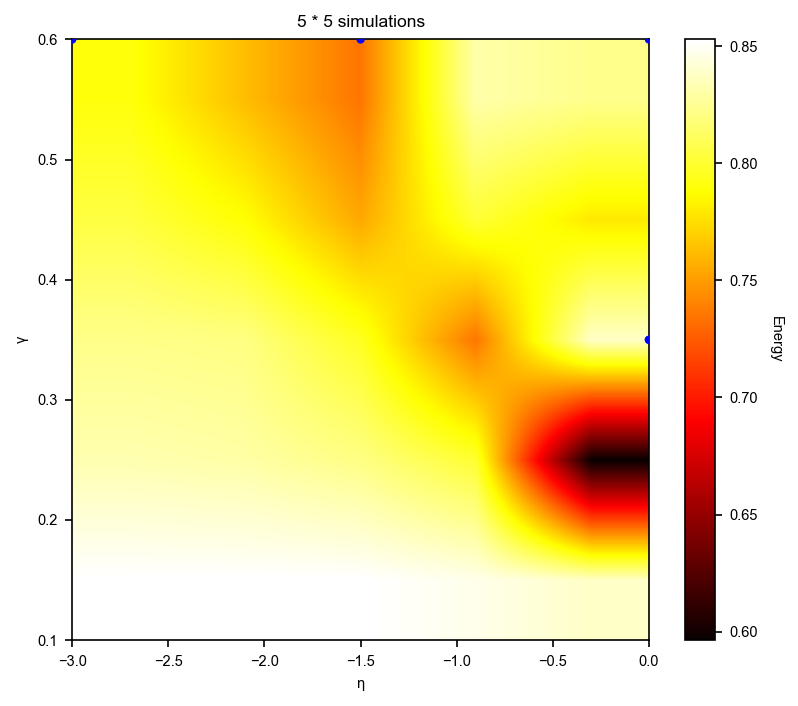

,network_index,gamma,eta,energy
0,0,0.60,0.0,0.632353
1,1,0.35,0.0,0.540347
2,2,0.35,0.0,0.735294
3,3,0.60,-1.5,0.705882
4,4,0.60,-3.0,0.786152


In [146]:
# Plot + overlay the white dots = each subject’s best-fit (eta, gamma)
plot_energy_landscape(etas, gammas, E, df_best=df_best,
                    title=f"{number_individual_etas} * {number_individual_gammas} simulations", savepath="/Users/adrian/Documents/01_projects/connectome_experiment_ai_gen/results/figure4_like_heatmap.png")

df_best

In [ ]:
import numpy as np
from scipy import linalg
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

class ESN:
    def __init__(self, mask, in_dim, res_dim, rho=0.95, seed=None):
        rng = np.random.RandomState(seed)
        # Reservoir weight: random uniform, masked by empirical topology
        W = rng.uniform(-1, 1, (res_dim, res_dim)) * mask
        # Rescale to desired spectral radius
        lam = np.max(np.abs(linalg.eigvals(W)))
        W *= (rho / lam) if lam > 0 else 1.0
        self.W, self.W_in = W, rng.uniform(-1, 1, (res_dim, in_dim + 1))
        self.W_out = None

    def _step(self, prev_state, u):
        pre = self.W_in.dot(np.hstack([1, u])) + self.W.dot(prev_state)
        return np.tanh(pre)

    def fit(self, U, Y, washout=100, alpha=1e-6):
        T = U.shape[0]
        states = np.zeros((T, self.W.shape[0]))
        x = np.zeros(self.W.shape[0])
        for t in range(T):
            x = self._step(x, U[t])
            states[t] = x
        # discard initial washout
        S, Uw, Yw = states[washout:], U[washout:], Y[washout:]
        X = np.hstack([np.ones((S.shape[0], 1)), Uw, S])
        reg = Ridge(alpha=alpha, fit_intercept=False).fit(X, Yw)
        self.W_out = reg.coef_
        return self

    def predict(self, U, washout=100):
        T = U.shape[0]
        states = np.zeros((T, self.W.shape[0]))
        x = np.zeros(self.W.shape[0])
        for t in range(T):
            x = self._step(x, U[t])
            states[t] = x
        S, Uw = states[washout:], U[washout:]
        X = np.hstack([np.ones((S.shape[0], 1)), Uw, S])
        return X.dot(self.W_out.T)

def evaluate(connectomes, U, Y, runs=1000, washout=100):
    """
    connectomes: np.ndarray of shape (N, N, M)
    U: inputs array of shape (T, in_dim)
    Y: targets array of shape (T, out_dim)
    returns: np.ndarray of M×runs MSE values
    """
    N, _, M = connectomes.shape
    perf = np.zeros((M, runs))
    for s in range(M):
        mask = (connectomes[:, :, s] != 0).astype(int)
        for r in range(runs):
            esn = ESN(mask, in_dim=U.shape[1], res_dim=N, rho=0.95, seed=r)
            esn.fit(U, Y, washout=washout)
            Ypred = esn.predict(U, washout=washout)
            perf[s, r] = mean_squared_error(Y[washout:], Ypred)
    return perf

# if __name__ == "__main__":
    # === Load your data ===
    # connectomes = np.load("connectomes.npy")  # shape (N, N, M)
    # U = np.load("inputs.npy")               # shape (T, in_dim)
    # Y = np.load("targets.npy")              # shape (T, out_dim)

    # Compute performance
    # perf = evaluate(connectomes, U, Y, runs=1000, washout=100)
    # np.save("esn_mse_results.npy", perf)
    # print("Saved ESN MSE matrix with shape:", perf.shape)
    pass


# ESNs

In [66]:
import numpy as np, pandas as pd
from reservoirpy.nodes import Reservoir, Ridge
from reservoirpy.mat_gen import spectral_radius

def mask_to_W(mask, rng, rho=0.9):
    M = (mask != 0).astype(float)
    W = rng.uniform(-1, 1, size=M.shape) * M
    np.fill_diagonal(W, 0.0)
    return spectral_radius(W, sr=rho)  # rescale to target spectral radius

def narma10_dataset(trials=1000, T=1200, seed=0):
    rng = np.random.default_rng(seed); data=[]
    for _ in range(trials):
        u = rng.uniform(0, .5, size=T).reshape(-1,1)
        y = np.zeros((T,1))
        for t in range(10, T):
            y[t] = 0.3*y[t-1] + 0.05*y[t-1]*y[t-10:t].sum() + 1.5*u[t-10]*u[t-1] + 0.1
        data.append((u, y))
    return data

def eval_subject(mask, trials=1000, rho=0.9, washout=200, seed=0):
    rng = np.random.default_rng(seed)
    W = mask_to_W(mask, rng, rho=rho)
    res = Reservoir(W.shape[0], W=W, sr=None, lr=1.0)   # use our W; no re-init
    readout = Ridge(ridge=1e-6)
    esn = res >> readout

    ds = narma10_dataset(trials=trials, seed=seed)
    mses=[]
    for U, Y in ds:
        esn = esn.fit(U[:washout], Y[:washout])  # warmup to init states
        yhat = esn.run(U[washout:], reset=False)
        mse = ((Y[washout:]-yhat)**2).mean()
        mses.append(float(mse))
    return np.mean(mses), np.std(mses)

# connectomes: (N, N, M)
A = all_connectomes
rows=[]
for m in range(A.shape[2]):
    np.fill_diagonal(A[:, :, m], 0)
    mean_mse, std_mse = eval_subject(A[:, :, m], trials=1, rho=0.9, washout=200, seed=123+m)
    rows.append({"subject": m, "mean_mse": mean_mse, "std_mse": std_mse})
    break
print(pd.DataFrame(rows))


TypeError: spectral_radius() got an unexpected keyword argument 'sr'

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score


def make_narma10(u, a=0.3, b=0.05, c=1.5, d=0.1):
    """
    Generate NARMA10 target for input u (shape: [T]).
    Returns y (shape: [T]) with standard warmup.
    """
    T = len(u)
    y = np.zeros(T)
    for t in range(10, T):
        y[t] = (a * y[t-1]
                + b * y[t-1] * np.sum(y[t-10:t])
                + c * u[t-10] * u[t-1]
                + d)
    return y

def make_narma10_dataset(n_trials=1000, T=1200, seed=0):
    """
    Build synthetic dataset: 1D input, 1D output (NARMA10).
    Returns list of (U, Y) pairs; each U is [T, 1], Y is [T, 1].
    """
    rng = np.random.default_rng(seed)
    data = []
    for _ in range(n_trials):
        u = rng.uniform(0, 0.5, size=T)  # classic NARMA10 input
        y = make_narma10(u)
        data.append((u.reshape(-1, 1), y.reshape(-1, 1)))
    return data


In [ ]:



# ---------------------------
# ESN core (NumPy)
# ---------------------------

def rescale_spectral_radius(W, rho_target=0.9, eps=1e-12):
    # Power iteration for largest eigenvalue magnitude
    v = np.random.default_rng().normal(size=(W.shape[0], 1))
    v /= np.linalg.norm(v) + eps
    for _ in range(100):
        v = W @ v
        n = np.linalg.norm(v) + eps
        v /= n
    # Rayleigh quotient approximation of spectral radius
    lam = float(np.linalg.norm(W @ v) / (np.linalg.norm(v) + eps))
    if lam < eps:
        return W  # already near zero
    return (rho_target / lam) * W

def init_reservoir_from_connectome(mask, weight_scale=1.0, rho=0.9, rng=None, keep_self_loops=False):
    """
    mask: (N, N) binary or weighted >0 indicates a connection i->j.
    Randomizes weights on those edges in [-1,1], zeros elsewhere, rescales to spectral radius rho.
    """
    rng = np.random.default_rng() if rng is None else rng
    M = (mask != 0).astype(float)
    # Random signs/weights on existing edges
    W = rng.uniform(-1.0, 1.0, size=M.shape) * M * weight_scale
    if not keep_self_loops:
        np.fill_diagonal(W, 0.0)
    # Spectral radius normalization
    W = rescale_spectral_radius(W, rho_target=rho)
    return W

def run_esn_trial(W, U, Y, ridge=1e-6, leak=1.0, washout=200, input_scale=1.0, bias_scale=0.0, rng=None):
    """
    W: (N, N) reservoir
    U: (T, input_dim)
    Y: (T, output_dim)
    Returns dict with metrics and optionally the trained readout.
    """
    rng = np.random.default_rng() if rng is None else rng
    N = W.shape[0]
    T, input_dim = U.shape
    out_dim = Y.shape[1]

    # Input matrix Win and bias
    Win = rng.uniform(-1, 1, size=(N, input_dim)) * input_scale
    b = rng.uniform(-1, 1, size=(N,)) * bias_scale

    # Run reservoir
    X = np.zeros((T, N))
    x = np.zeros(N)
    for t in range(T):
        pre = Win @ U[t] + W @ x + b
        x_new = np.tanh(pre)
        x = (1 - leak) * x + leak * x_new  # leaky integration
        X[t] = x

    # Train readout on post-washout states
    Xtr = X[washout:]
    Ytr = Y[washout:]

    # Add bias term in readout (column of ones)
    Xtr_aug = np.hstack([Xtr, np.ones((Xtr.shape[0], 1))])
    reg = Ridge(alpha=ridge, fit_intercept=False)
    reg.fit(Xtr_aug, Ytr)

    # Evaluate on the same sequence (can split if you have separate val/test)
    Yhat = reg.predict(Xtr_aug)
    mse = float(mean_squared_error(Ytr, Yhat))
    r2 = float(r2_score(Ytr, Yhat))

    return {"mse": mse, "r2": r2, "readout": reg, "states": X}


# ---------------------------
# Batch runner
# ---------------------------

def evaluate_connectome_esn_set(connectomes, trials=1000, task="narma10",
                                seq_len=1200, washout=200, rho=0.9, ridge=1e-6,
                                leak=1.0, input_scale=1.0, bias_scale=0.0, seed=42,
                                user_dataset=None):
    """
    connectomes: np.ndarray of shape (N, N, M)
    task: "narma10" or "custom"
    user_dataset: list of (U, Y) pairs if task="custom"
                  U: [T, input_dim], Y: [T, output_dim]
    Returns: (df_subject_metrics, df_overall)
    """
    rng = np.random.default_rng(seed)
    N, N2, M = connectomes.shape
    assert N == N2, "Connectomes must be (N, N, M)."

    # Build dataset
    if task == "narma10":
        dataset = make_narma10_dataset(n_trials=trials, T=seq_len, seed=seed)
    elif task == "custom":
        assert user_dataset is not None and len(user_dataset) >= trials, \
            "Provide user_dataset = [(U, Y), ...] with at least `trials` items."
        dataset = user_dataset[:trials]
    else:
        raise ValueError("Unknown task")

    records = []

    for m in range(M):
        mask = connectomes[:, :, m]
        # Use connectome as topology mask
        W = init_reservoir_from_connectome(mask, rho=rho, rng=rng)

        subj_mses, subj_r2s = [], []
        for trial_idx in range(trials):
            U, Y = dataset[trial_idx]
            # Safety: ensure 2D
            U = np.atleast_2d(U)
            Y = np.atleast_2d(Y)
            res = run_esn_trial(
                W, U, Y,
                ridge=ridge, leak=leak, washout=washout,
                input_scale=input_scale, bias_scale=bias_scale,
                rng=rng
            )
            subj_mses.append(res["mse"])
            subj_r2s.append(res["r2"])

        records.append({
            "subject_index": m,
            "mean_mse": float(np.mean(subj_mses)),
            "std_mse": float(np.std(subj_mses)),
            "mean_r2": float(np.mean(subj_r2s)),
            "std_r2": float(np.std(subj_r2s)),
            "n_trials": trials
        })

    df_subjects = pd.DataFrame(records)
    df_overall = pd.DataFrame({
        "overall_mean_mse": [df_subjects["mean_mse"].mean()],
        "overall_std_mse": [df_subjects["mean_mse"].std()],
        "overall_mean_r2": [df_subjects["mean_r2"].mean()],
        "overall_std_r2": [df_subjects["mean_r2"].std()],
        "subjects": [M],
        "trials_per_subject": [trials]
    })

    return df_subjects, df_overall


# ---------------------------
# Example usage (edit me)
# ---------------------------
# if __name__ == "__main__":
    # Example: fabricate a small connectome set (replace with your real data)
    # N, M = 90, 5
    # rng = np.random.default_rng(0)
    # connectomes = (rng.random((N, N, M)) < 0.05).astype(float)  # 5% density mask
for m in range(all_connectomes.shape[2]):
    np.fill_diagonal(all_connectomes[:, :, m], 0)

# Evaluate on NARMA10 with 1000 trials/subject
df_subj, df_all = evaluate_connectome_esn_set(
    all_connectomes,
    trials=1000,
    task="narma10",
    seq_len=1200,
    washout=200,
    rho=0.9,
    ridge=1e-6,
    leak=1.0,
    input_scale=1.0,
    bias_scale=0.0,
    seed=123
)

print(df_subj.head())
print(df_all)


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_6931/3517889613.py:19: RuntimeWarning: overflow encountered in scalar multiply
  + b * y[t-1] * np.sum(y[t-10:t])
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_6931/3517889613.py:47: RuntimeWarning: divide by zero encountered in matmul
  v = W @ v
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_6931/3517889613.py:47: RuntimeWarning: overflow encountered in matmul
  v = W @ v
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_6931/3517889613.py:47: RuntimeWarning: invalid value encountered in matmul
  v = W @ v
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_6931/3517889613.py:51: RuntimeWarning: divide by zero encountered in matmul
  lam = float(np.linalg.norm(W @ v) / (np.linalg.norm(v) + eps))
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_6931/3517889613.py:51: RuntimeWarning: overflow encountered in matmul
  lam = float(np.linalg.norm(W @ v) / (np.linalg.norm(v) + eps))

ValueError: Input y contains infinity or a value too large for dtype('float64').

training r2 score:  0.9817475390786201
test r2 score:  0.9723833331090025


/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3437: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3437: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3437: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/echoes/esn/_base.py:312: RuntimeWarning: divide by zero encountered in matmul
  W_out = (np.linalg.pinv(full_states) @ outputs).T
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/echoes/esn/_base.py:312: RuntimeWarning: overflow encountered in matmul
  W_out = (np.linalg.pinv(full_states) @ outputs).T
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/echoes/esn/_base.py:312: RuntimeWarning: invalid value

(array([ 1.,  0.,  2.,  6., 69., 21.,  0.,  1.,  0.,  1.]),
 array([-1112.36131502,  -876.85357398,  -641.34583294,  -405.83809189,
         -170.33035085,    65.17739019,   300.68513123,   536.19287227,
          771.70061331,  1007.20835436,  1242.7160954 ]),
 <BarContainer object of 10 artists>)

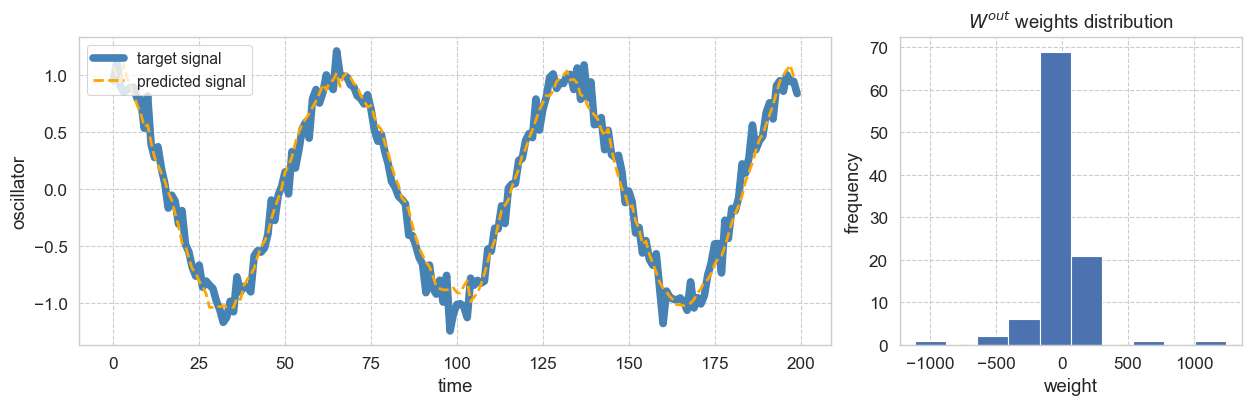

In [ ]:
"""
=========================================================
ESNRegressor example
=========================================================

This example shows a minimal example of Echo State Network
applied to a regression problem.
"""
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

from echoes import ESNRegressor
from echoes.plotting import set_mystyle

set_mystyle()  # optional: set aesthetics


# Prepare synthetic data 
x = np.linspace(0, 30*np.pi, 1000).reshape(-1,1)
inputs = np.sin(x) + np.random.normal(scale=.1, size=x.shape)
outputs = np.cos(x) + np.random.normal(scale=.1, size=x.shape)
# x.shape, inputs.shape, outputs.shape # x.shape, inputs.shape, outputs.shape

X_train, X_test, y_train, y_test = train_test_split(inputs, outputs, test_size=.3, shuffle=False)

esn = ESNRegressor(
    spectral_radius=.95,
    leak_rate=.4,
    n_transient=100,    
    regression_method="pinv",
    random_state=42
)
esn.fit(X_train, y_train)

print("training r2 score: ", esn.score(X_train, y_train))
print("test r2 score: ", esn.score(X_test, y_test))

# Get prediction for plotting
y_pred = esn.predict(X_test)

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, (1, 2))
plt.plot(y_test[esn.n_transient:], label='target signal',
         color="steelblue", linewidth=5.5)
plt.plot(y_pred[esn.n_transient:], label='predicted signal',
         linestyle='--', color="orange",  linewidth=2,)
plt.ylabel("oscillator")
plt.xlabel('time')
plt.legend(fontsize=("small"), loc=2)

plt.subplot(1, 3, 3)
plt.title(r"$W^{out}$ weights distribution")
plt.xlabel('weight')
plt.ylabel('frequency')
plt.hist(esn.W_out_.flat)